# H-1B Wage Level Analyzer
## Exploratory Analysis of Wage Classification Patterns Across Fortune 500 H-1B Sponsors

**Author:** Vamika Negi
**Data:** DOL LCA Disclosure Data FY2024 · BLS OEWS National Wage Data May 2024
**Tools:** Python · pandas · DuckDB · matplotlib · seaborn

---
### Business Problem
Do major H-1B sponsors systematically classify technology roles at lower prevailing
wage levels (Level I/II) relative to BLS occupational benchmarks? This analysis
quantifies wage-level distribution patterns and offered-wage gaps across 20+ companies
to inform pay equity strategy and talent acquisition benchmarking.

In [1]:
import sys
import os

# Absolute path fix — works regardless of how Jupyter was launched
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'src'))

# Fallback: hardcode your actual path (replace with your username)
sys.path.insert(0, '/Users/vamikanegi/Desktop/h1b-wage-level-analyzer/src')

import config

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import duckdb

sns.set_theme(style="whitegrid", font_scale=1.05)
pd.set_option("display.float_format", "${:,.0f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("All imports successful.")
print(f"H-1B clean file: {config.H1B_CLEAN_FILE}")
print(f"BLS clean file:  {config.BLS_CLEAN_FILE}")

All imports successful.
H-1B clean file: /Users/vamikanegi/Desktop/h1b-wage-level-analyzer/data/processed/h1b_clean.csv
BLS clean file:  /Users/vamikanegi/Desktop/h1b-wage-level-analyzer/data/processed/bls_clean.csv


In [2]:
h1b = pd.read_csv(config.H1B_CLEAN_FILE)
bls = pd.read_csv(config.BLS_CLEAN_FILE)

print("=== H-1B Dataset ===")
print(f"  Rows:           {len(h1b):,}")
print(f"  Companies:      {h1b['COMPANY'].nunique()}")
print(f"  SOC codes:      {h1b['SOC_CODE'].nunique()}")
print(f"  Wage range:     ${h1b['OFFERED_WAGE_ANNUAL'].min():,.0f} – "
      f"${h1b['OFFERED_WAGE_ANNUAL'].max():,.0f}")
print()
print("=== BLS Benchmark Dataset ===")
print(f"  Occupations:    {len(bls):,}")
print(f"  Median range:   ${bls['A_MEDIAN'].min():,.0f} – "
      f"${bls['A_MEDIAN'].max():,.0f}")
print()
print("=== Missing Value Check ===")
key_cols = ['COMPANY','SOC_CODE','OFFERED_WAGE_ANNUAL','PW_WAGE_LEVEL']
print(h1b[key_cols].isnull().sum().to_string())

=== H-1B Dataset ===
  Rows:           21,535
  Companies:      40
  SOC codes:      26
  Wage range:     $41,184 – $423,600

=== BLS Benchmark Dataset ===
  Occupations:    36
  Median range:   $60,340 – $140,910

=== Missing Value Check ===
COMPANY                   0
SOC_CODE                  0
OFFERED_WAGE_ANNUAL       0
PW_WAGE_LEVEL          1502


## Exploratory Analysis
### Filing volume, wage levels, and wage gap findings

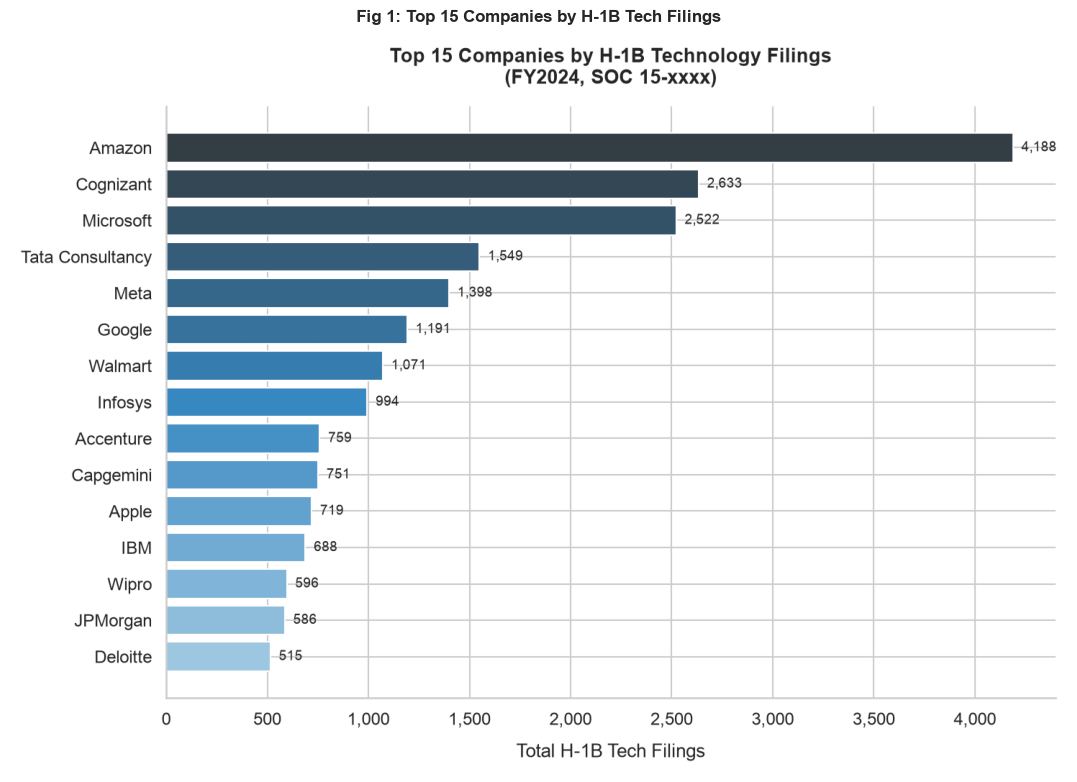

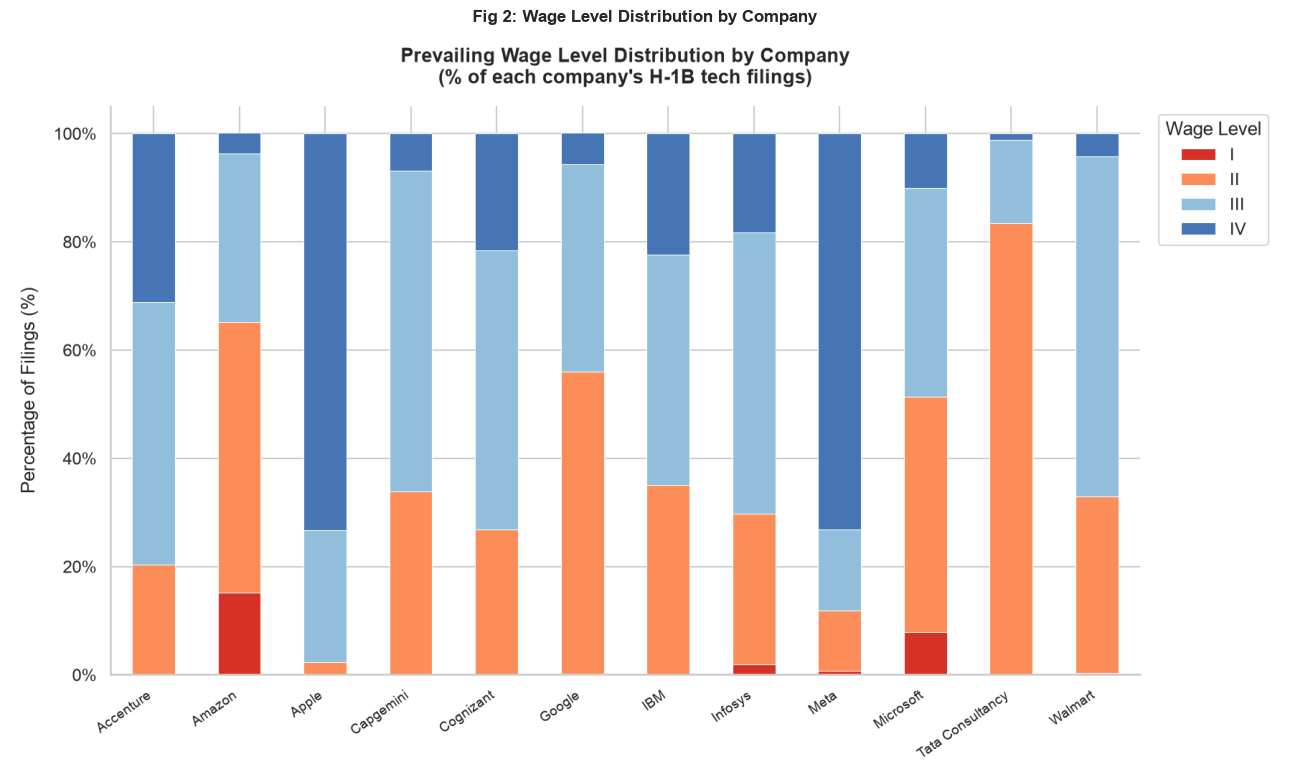

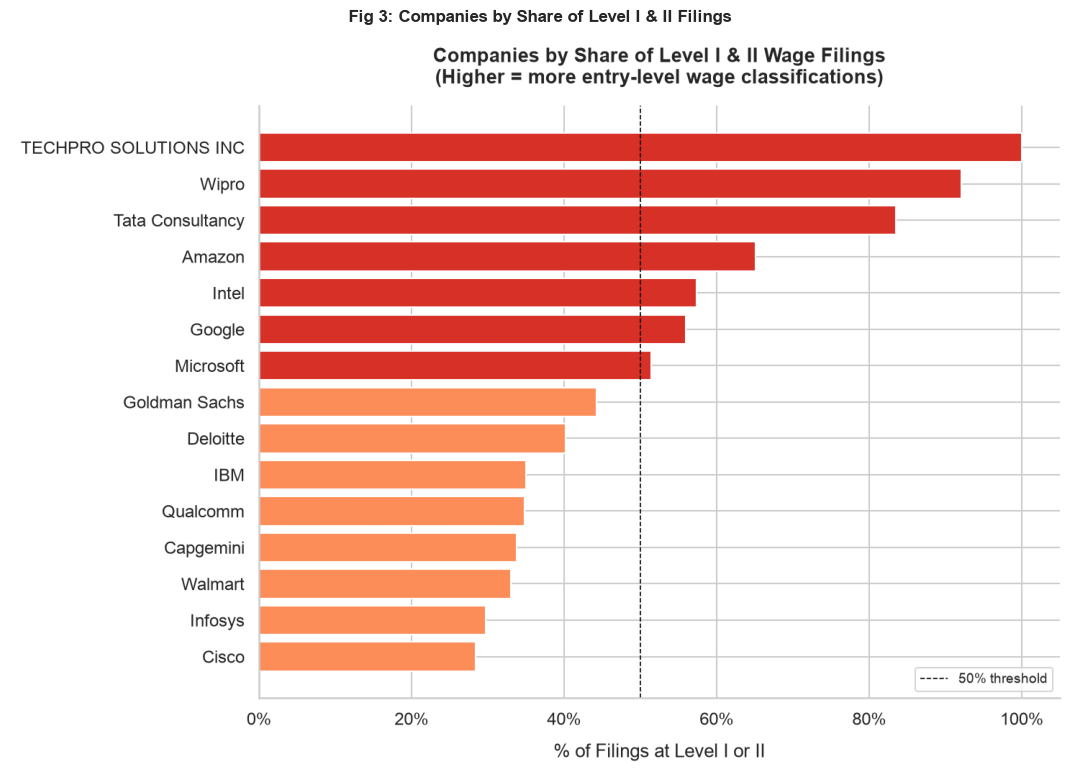

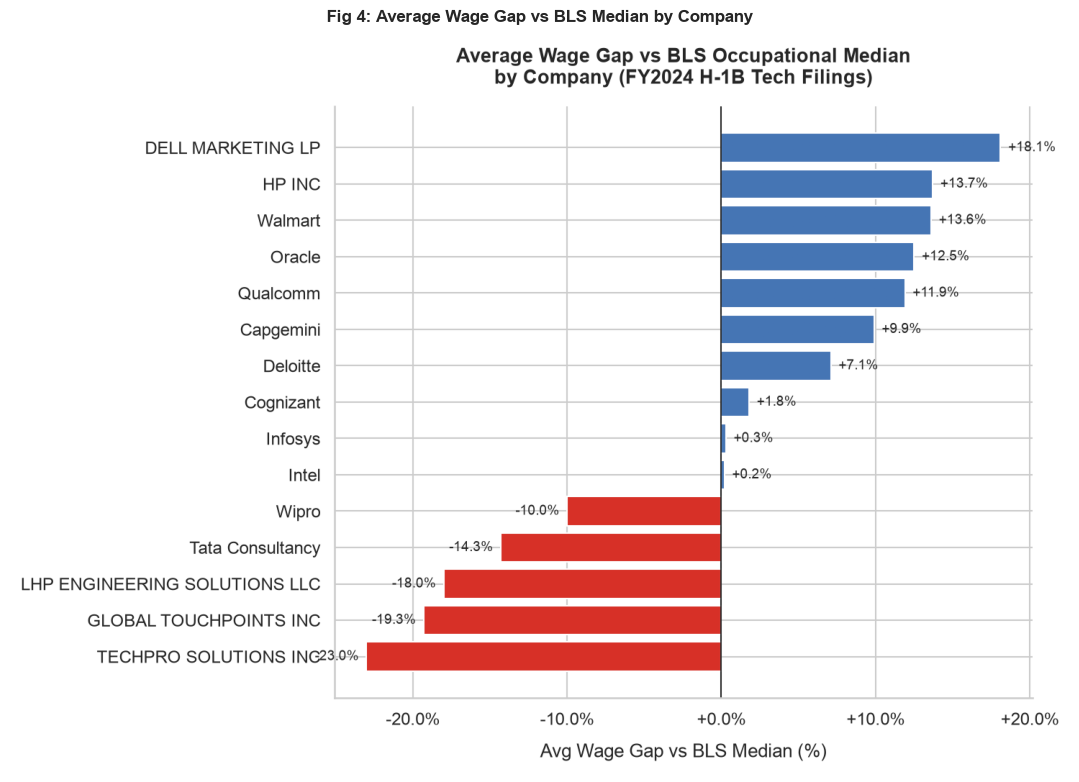

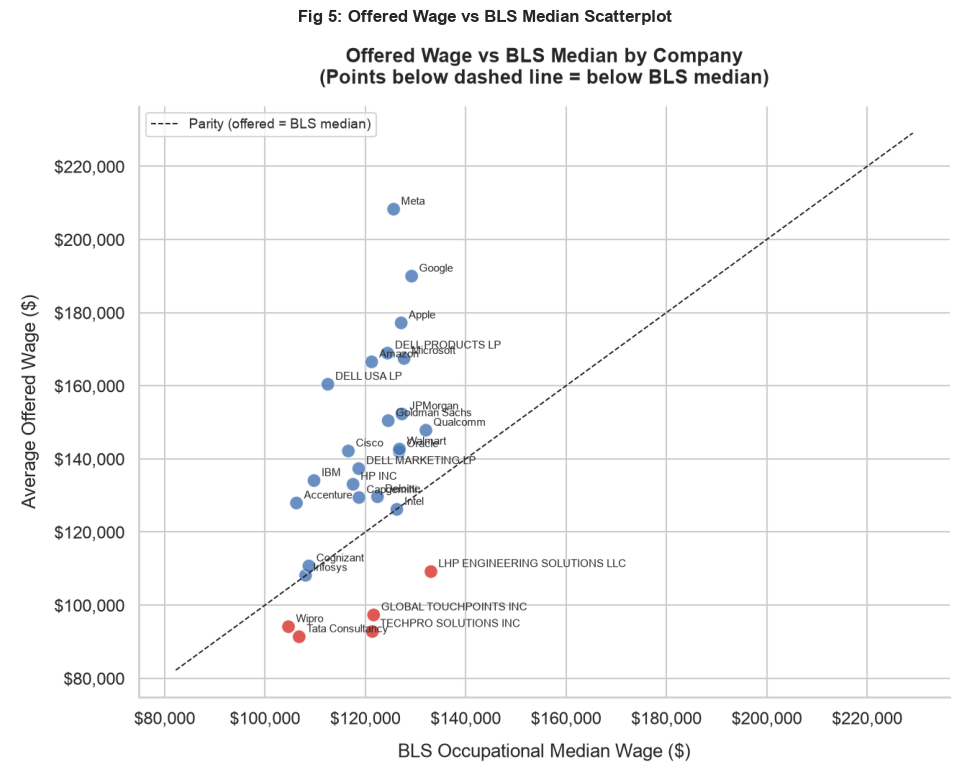

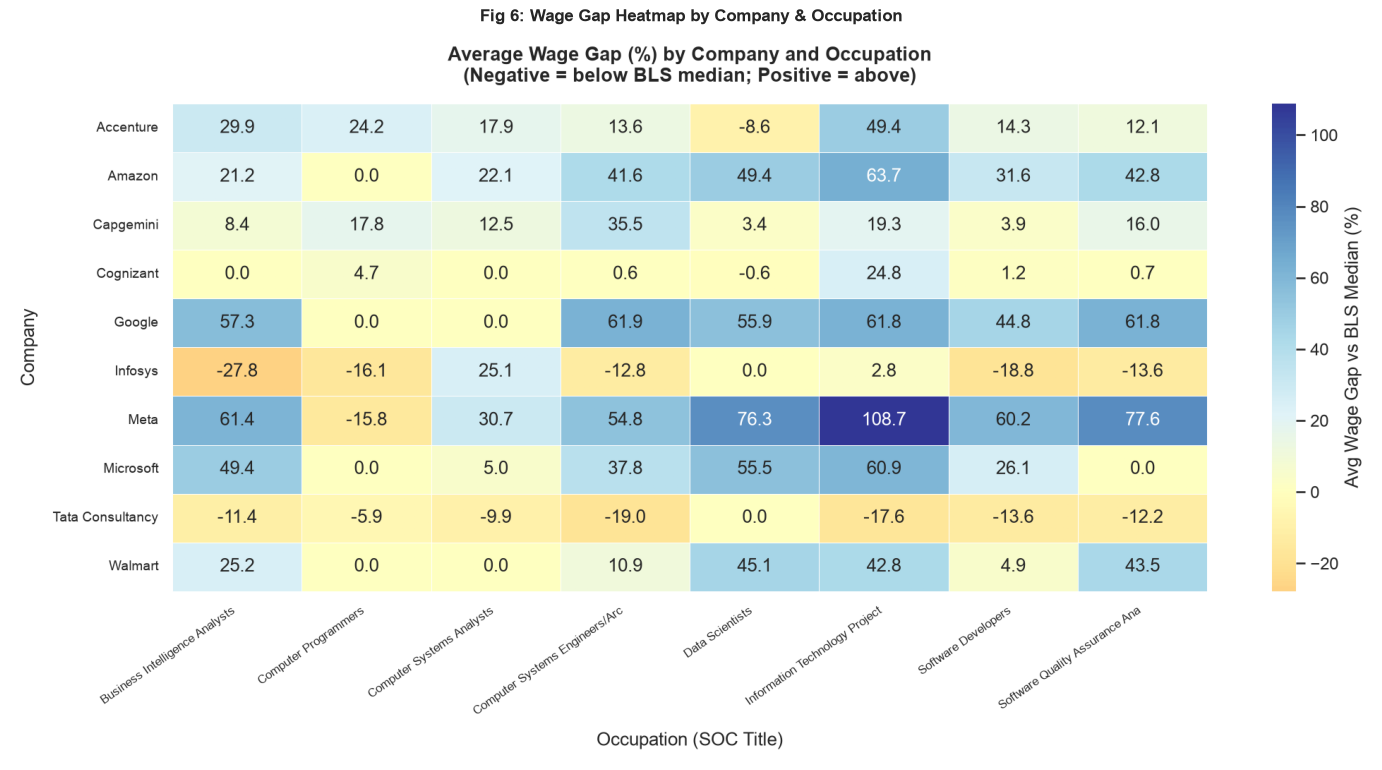

In [3]:
figures = [
    ("fig1_top_companies.png",       "Fig 1: Top 15 Companies by H-1B Tech Filings"),
    ("fig2_wage_level_dist.png",     "Fig 2: Wage Level Distribution by Company"),
    ("fig3_level1_share.png",        "Fig 3: Companies by Share of Level I & II Filings"),
    ("fig4_wage_gap_company.png",    "Fig 4: Average Wage Gap vs BLS Median by Company"),
    ("fig5_scatter_offered_vs_bls.png", "Fig 5: Offered Wage vs BLS Median Scatterplot"),
    ("fig6_heatmap_gap_by_soc.png",  "Fig 6: Wage Gap Heatmap by Company & Occupation"),
]

for fname, title in figures:
    path = config.FIGURES / fname
    if path.exists():
        img = mpimg.imread(str(path))
        fig, ax = plt.subplots(figsize=(14, 8))
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Missing: {fname}")

In [4]:
import pandas as pd

con = duckdb.connect(str(config.DB_FILE))

print("=== Top 10 Companies by Filings ===")
df1 = pd.read_csv(config.TABLES / "q1_top_companies.csv")
display(df1[["COMPANY", "total_filings", "avg_offered_wage"]].head(10))

print("\n=== Companies by Level I Share (Top 10) ===")
df3 = pd.read_csv(config.TABLES / "q3_level1_share.csv")
display(df3[["COMPANY", "total_filings", "pct_level1", "pct_level1_or_2"]]
        .sort_values("pct_level1", ascending=False).head(10))

print("\n=== Wage Gap vs BLS Median by Company ===")
df4 = pd.read_csv(config.TABLES / "q4_wage_gap.csv")
display(df4[["COMPANY", "avg_offered_wage", "avg_bls_median",
             "avg_wage_gap", "avg_wage_gap_pct"]]
        .sort_values("avg_wage_gap_pct", ascending=True))

con.close()

=== Top 10 Companies by Filings ===


,COMPANY,total_filings,avg_offered_wage
0,Amazon,4188,"$166,530"
1,Cognizant,2633,"$110,716"
2,Microsoft,2522,"$167,449"
3,Tata Consultancy,1549,"$91,355"
4,Meta,1398,"$208,281"
5,Google,1191,"$189,966"
6,Walmart,1071,"$142,685"
7,Infosys,994,"$108,147"
8,Accenture,759,"$127,922"
9,Capgemini,751,"$129,425"



=== Companies by Level I Share (Top 10) ===


,COMPANY,total_filings,pct_level1,pct_level1_or_2
0,TECHPRO SOLUTIONS INC,15,$40,$100
1,Amazon,4145,$15,$65
2,Goldman Sachs,158,$13,$44
3,Intel,397,$11,$57
4,Microsoft,2428,$8,$51
5,Deloitte,495,$4,$40
6,Infosys,994,$2,$30
7,Meta,1150,$1,$12
9,JPMorgan,394,$0,$9
8,Walmart,794,$0,$33



=== Wage Gap vs BLS Median by Company ===


,COMPANY,avg_offered_wage,avg_bls_median,avg_wage_gap,avg_wage_gap_pct
0,TECHPRO SOLUTIONS INC,"$92,793","$121,405","$-28,611",$-23
1,GLOBAL TOUCHPOINTS INC,"$97,313","$121,654","$-24,341",$-19
2,LHP ENGINEERING SOLUTIONS LLC,"$109,171","$133,080","$-23,909",$-18
3,Tata Consultancy,"$91,355","$106,809","$-15,454",$-14
4,Wipro,"$94,103","$104,684","$-10,581",$-10
5,Intel,"$126,189","$126,277",$-88,$0
6,Infosys,"$108,147","$108,096",$51,$0
7,Cognizant,"$110,716","$108,743","$1,973",$2
8,Deloitte,"$129,638","$122,425","$7,212",$7
9,Capgemini,"$129,425","$118,734","$10,690",$10


## Key Findings

1. **Filing volume:** Amazon filed the most H-1B tech applications (4,188),
   nearly double the second-largest sponsor (Cognizant at 2,633).

2. **Wage level classification:** Wipro (93%) and Tata Consultancy (83%)
   filed the highest shares of Level I & II applications, suggesting a
   preference for entry-level prevailing wage benchmarks despite hiring
   experienced engineers.

3. **BLS wage gap:** [Fill in from your q4_wage_gap.csv — which companies
   are most below the BLS median, and by how much?]

4. **Occupation patterns:** Software Developers (SOC 15-1252) represent
   the majority of filings across all companies. Amazon and Accenture show
   the largest positive gaps in this role.

5. **Methodology note:** Offered wages below the BLS median are lawful —
   the legal floor is the prevailing wage level, not the median. These
   findings describe classification patterns, not violations.

## Limitations

- **SOC code matching:** Not all H-1B SOC codes matched BLS benchmarks
  exactly, reducing the sample for wage gap analysis.
- **Single fiscal year:** FY2024 data only; multi-year trends would
  strengthen conclusions.
- **No seniority data:** Level I wages are appropriate for genuinely
  entry-level roles; the data cannot distinguish seniority level from
  wage suppression.
- **Company name matching:** Employer name standardization is approximate;
  subsidiaries may be undercounted.

## Business Recommendations

- **For job seekers:** Use Level III/IV prevailing wages as a negotiation
  floor when evaluating H-1B sponsor offers.
- **For HR teams:** Benchmark internal offer distributions against this
  company-level data to identify competitive positioning gaps.
- **For researchers:** A multi-year panel (FY2020–FY2024) would allow
  trend analysis of wage level inflation or suppression over time.